In [1]:
# ==============================================================================
# 🛡️ Anti-Spoofing Facial Robusto en Escenarios de Desbalance Extremo: 
#    EfficientNet-B0 con Focal Loss y Weighted Sampling sobre LCC-FASD
# ==============================================================================
# Proyecto Final - Maestría de Inteligencia Artificial
# Universidad Nacional de Ingeniería
# Facultad de Ingeniería Industrial y de Sistemas - Unidad de Postgrado
#
# Grupo 2:
#   - Franklin Enrique Alegria Barboza
#   - Jose Luis Espinoza Chamaya
#   - Amit Roy Flores Rivera
#   - Raquel Medianero Huari
#   - Yasmin Mariela Urrego Montoya
#
# Profesora: Mg. Elian Raquel Laura Riveros
#
# 📌 Objetivo: Clasificación binaria (Real vs. Spoof) con manejo de desbalance 89:11.
# 🧠 Modelo: EfficientNet-B0 (Transfer Learning) + Focal Loss + WeightedRandomSampler.
# 📊 Resultado Clave: ACER = 5.94% | APCER = 1.05% | Accuracy = 98.55%
# ==============================================================================

In [2]:
# ==========================================
# CELDA 1: INSTALACIONES Y SETUP
# ==========================================

!pip install -q timm opencv-python scikit-learn matplotlib seaborn pandas tqdm grad-cam albumentations

print("✅ Instalaciones completadas!")

✅ Instalaciones completadas!


In [3]:
# ==========================================
# CELDA 2: IMPORTS Y CONFIGURACIÓN
# ==========================================

import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import warnings
warnings.filterwarnings('ignore')

# Configuración
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_EPOCHS = 30
LR = 1e-4
SEED = 42
PATIENCE = 5  # Early stopping
DATA_ROOT = Path("data/lcc_fasd/LCC_FASD")

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"🖥️ Dispositivo: {DEVICE}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")

🖥️ Dispositivo: cuda
🎮 GPU: NVIDIA RTX A4000


In [4]:
# ==========================================
# CELDA 3: VERIFICACIÓN DEL DATASET
# ==========================================

if not DATA_ROOT.exists():
    print("❌ No se encontró el dataset en data/lcc_fasd/LCC_FASD")
    print("📥 Por favor, descarga y descomprime lcc-fasd.zip en data/lcc_fasd/")
else:
    print(f"✅ Dataset encontrado en: {DATA_ROOT}")
    print("📂 Estructura esperada:")
    for split in ['LCC_FASD_training', 'LCC_FASD_development', 'LCC_FASD_evaluation']:
        for cls in ['real', 'spoof']:
            folder = DATA_ROOT / split / cls
            if folder.exists():
                count = len(list(folder.glob("*.*")))
                print(f"   {split}/{cls}: {count} archivos")

✅ Dataset encontrado en: data/lcc_fasd/LCC_FASD
📂 Estructura esperada:
   LCC_FASD_training/real: 1223 archivos
   LCC_FASD_training/spoof: 7076 archivos
   LCC_FASD_development/real: 405 archivos
   LCC_FASD_development/spoof: 2543 archivos
   LCC_FASD_evaluation/real: 314 archivos
   LCC_FASD_evaluation/spoof: 7267 archivos



📊 DISTRIBUCIÓN DEL DATASET LCC-FASD
     Split Clase  Imágenes
     Train  real      1223
     Train spoof      7076
Validation  real       405
Validation spoof      2543
      Test  real       314
      Test spoof      7266

📈 Total Real: 1942 (10.3%)
📈 Total Spoof: 16885 (89.7%)
📈 Total Imágenes: 18827
⚖️ Ratio desbalance spoof:real = 8.7:1


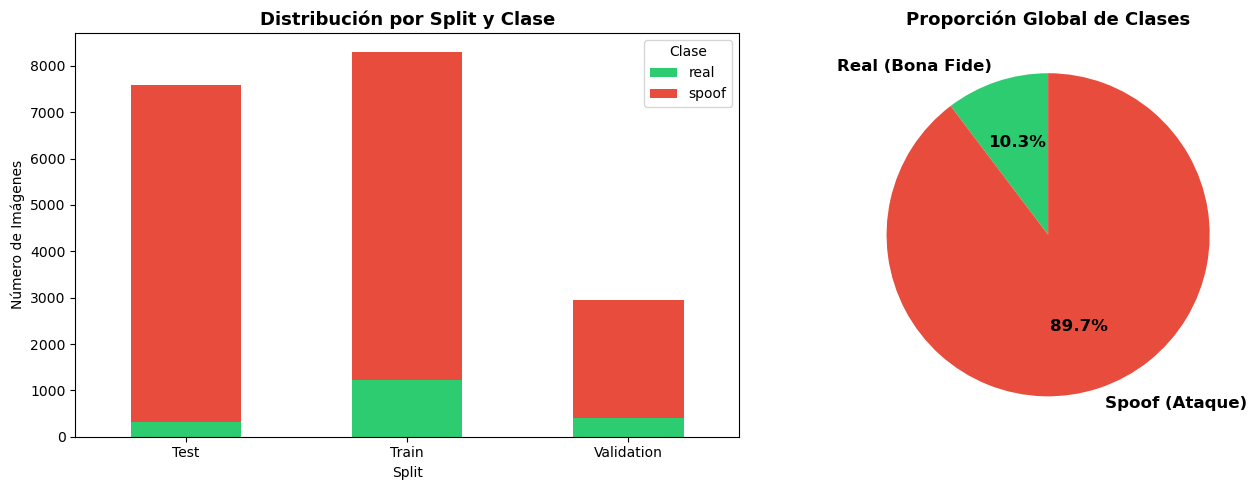


✅ Gráfico guardado como eda_distribution.png


In [5]:
# ==========================================
# CELDA 4: EDA - ANÁLISIS EXPLORATORIO
# ==========================================

splits = ['LCC_FASD_training', 'LCC_FASD_development', 'LCC_FASD_evaluation']
split_names = {'LCC_FASD_training': 'Train', 'LCC_FASD_development': 'Validation', 'LCC_FASD_evaluation': 'Test'}

eda_rows = []
for split in splits:
    for cls in ['real', 'spoof']:
        folder = DATA_ROOT / split / cls
        if folder.exists():
            files = []
            for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG', '*.bmp']:
                files.extend(list(folder.glob(ext)))
            eda_rows.append({'Split': split_names[split], 'Clase': cls, 'Imágenes': len(files)})

df_eda = pd.DataFrame(eda_rows)
total_real = sum(r['Imágenes'] for r in eda_rows if r['Clase'] == 'real')
total_spoof = sum(r['Imágenes'] for r in eda_rows if r['Clase'] == 'spoof')
total = total_real + total_spoof

print("\n" + "="*60)
print("📊 DISTRIBUCIÓN DEL DATASET LCC-FASD")
print("="*60)
print(df_eda.to_string(index=False))
print(f"\n📈 Total Real: {total_real} ({100*total_real/total:.1f}%)")
print(f"📈 Total Spoof: {total_spoof} ({100*total_spoof/total:.1f}%)")
print(f"📈 Total Imágenes: {total}")
print(f"⚖️ Ratio desbalance spoof:real = {total_spoof/total_real:.1f}:1")

# Gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pivot = df_eda.pivot(index='Split', columns='Clase', values='Imágenes')
pivot.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución por Split y Clase', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de Imágenes')
axes[0].legend(title='Clase')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie([total_real, total_spoof], labels=['Real (Bona Fide)', 'Spoof (Ataque)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90,
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Proporción Global de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Gráfico guardado como eda_distribution.png")

In [6]:
# ==========================================
# CELDA 5: DATASET PERSONALIZADO Y TRANSFORMACIONES
# ==========================================

class LCCFASDDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.root = Path(root) / split
        self.transform = transform
        self.samples = []
        for cls_name, label in [('real', 0), ('spoof', 1)]:
            cls_dir = self.root / cls_name
            if cls_dir.exists():
                for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG', '*.bmp']:
                    for fpath in cls_dir.glob(ext):
                        self.samples.append((str(fpath), label))
        print(f"  [{split}] {len(self.samples)} imágenes ({sum(1 for _,l in self.samples if l==0)} real, {sum(1 for _,l in self.samples if l==1)} spoof)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        if self.transform:
            img = self.transform(image=img)['image']
        else:
            img = torch.tensor(img).permute(2, 0, 1).float() / 255.0
        return img, torch.tensor(label, dtype=torch.long)

# Transformaciones
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.ImageCompression(quality_lower=70, quality_upper=100, p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

print("📦 Cargando datasets...")
train_dataset = LCCFASDDataset(DATA_ROOT, 'LCC_FASD_training', transform=train_transform)
val_dataset = LCCFASDDataset(DATA_ROOT, 'LCC_FASD_development', transform=val_transform)
test_dataset = LCCFASDDataset(DATA_ROOT, 'LCC_FASD_evaluation', transform=val_transform)

📦 Cargando datasets...
  [LCC_FASD_training] 8299 imágenes (1223 real, 7076 spoof)
  [LCC_FASD_development] 2948 imágenes (405 real, 2543 spoof)
  [LCC_FASD_evaluation] 7580 imágenes (314 real, 7266 spoof)


In [7]:
# ==========================================
# CELDA 6: DATALOADERS CON SAMPLER PARA DESBALANCE
# ==========================================

train_labels = [label for _, label in train_dataset.samples]
class_counts = np.bincount(train_labels)
class_weights = 1. / class_counts
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

print(f"✅ DataLoaders creados")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")
print(f"   Class weights: Real={class_weights[0]:.4f}, Spoof={class_weights[1]:.4f}")

✅ DataLoaders creados
   Train batches: 260
   Val batches: 93
   Test batches: 237
   Class weights: Real=0.0008, Spoof=0.0001


In [8]:
# ==========================================
# CELDA 7: MODELO EFFICIENTNET-B0 REGULARIZADO
# ==========================================

class FASModel(nn.Module):
    def __init__(self, model_name='efficientnet_b0', num_classes=2, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        self.feature_dim = self.backbone.num_features
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),  # Dropout fuerte
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

model = FASModel('efficientnet_b0', num_classes=2, pretrained=True).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🧠 Modelo: EfficientNet-B0")
print(f"   Parámetros totales: {total_params:,}")
print(f"   Parámetros entrenables: {trainable_params:,}")

🧠 Modelo: EfficientNet-B0
   Parámetros totales: 4,335,998
   Parámetros entrenables: 4,335,998


In [9]:
# ==========================================
# CELDA 8: FOCAL LOSS + LABEL SMOOTHING + OPTIMIZADOR
# ==========================================

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        ce_loss = nn.functional.cross_entropy(
            logits, targets, reduction='none', label_smoothing=self.label_smoothing
        )
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

criterion = FocalLoss(gamma=2.0, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print("✅ Focal Loss con Label Smoothing (0.1)")
print("   Weight Decay: 1e-3")
print("   Dropout: 0.5 en cabeza")

✅ Focal Loss con Label Smoothing (0.1)
   Weight Decay: 1e-3
   Dropout: 0.5 en cabeza


In [10]:
# ==========================================
# CELDA 9: FUNCIONES DE EVALUACIÓN Y MÉTRICAS ISO
# ==========================================

def compute_pad_metrics(y_true, y_pred, y_prob=None):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    apcer = fn / (fn + tp) if (fn + tp) > 0 else 0
    bpcer = fp / (fp + tn) if (fp + tn) > 0 else 0
    acer = (apcer + bpcer) / 2
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    eer, eer_threshold = None, None
    if y_prob is not None:
        y_prob = np.array(y_prob)
        fpr, tpr, thresholds = roc_curve(y_true, y_prob)
        fnr = 1 - tpr
        eer_idx = np.argmin(np.abs(fpr - fnr))
        eer = fpr[eer_idx]
        eer_threshold = thresholds[eer_idx]

    return {
        'APCER': apcer, 'BPCER': bpcer, 'ACER': acer,
        'HTER': acer, 'EER': eer, 'EER_Threshold': eer_threshold,
        'Accuracy': accuracy, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
    }

def print_metrics(metrics, title="Métricas"):
    print(f"\n{'='*50}")
    print(f"📊 {title}")
    print(f"{'='*50}")
    print(f"  APCER:  {metrics['APCER']:.4f} ({100*metrics['APCER']:.2f}%)")
    print(f"  BPCER:  {metrics['BPCER']:.4f} ({100*metrics['BPCER']:.2f}%)")
    print(f"  ACER:   {metrics['ACER']:.4f} ({100*metrics['ACER']:.2f}%)")
    print(f"  HTER:   {metrics['HTER']:.4f} ({100*metrics['HTER']:.2f}%)")
    if metrics['EER'] is not None:
        print(f"  EER:    {metrics['EER']:.4f} ({100*metrics['EER']:.2f}%)")
    print(f"  Acc:    {metrics['Accuracy']:.4f} ({100*metrics['Accuracy']:.2f}%)")
    print(f"  TP={metrics['TP']}, TN={metrics['TN']}, FP={metrics['FP']}, FN={metrics['FN']}")

@torch.no_grad()
def evaluate_model(model, dataloader, device=DEVICE):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in tqdm(dataloader, desc="Evaluando"):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())
    metrics = compute_pad_metrics(all_labels, all_preds, all_probs)
    return metrics, all_labels, all_preds, all_probs

print("✅ Funciones de evaluación listas")

✅ Funciones de evaluación listas


In [11]:
# ==========================================
# CELDA 10: ENTRENAMIENTO CON EARLY STOPPING
# ==========================================

train_losses = []
val_acers = []
best_val_acer = float('inf')
epochs_no_improve = 0
best_model_state = None

print(f"\n🚀 Iniciando entrenamiento por {NUM_EPOCHS} épocas (Regularización fuerte)")
print(f"   Dropout=0.5, Label Smoothing=0.1, Weight Decay=1e-3\n")

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]")
    for images, labels in pbar:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*train_correct/train_total:.1f}%'})

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    val_metrics, _, _, _ = evaluate_model(model, val_loader)
    val_acers.append(val_metrics['ACER'])
    scheduler.step()

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}:")
    print(f"  Train Loss: {epoch_loss:.4f}, Train Acc: {100*train_correct/train_total:.2f}%")
    print(f"  Val ACER: {val_metrics['ACER']:.4f}")

    if val_metrics['ACER'] < best_val_acer:
        best_val_acer = val_metrics['ACER']
        best_model_state = model.state_dict().copy()
        torch.save(best_model_state, 'best_efficientnet_b0_lcc_fasd.pth')
        epochs_no_improve = 0
        print(f"  ✅ ¡Nuevo mejor modelo! ACER={val_metrics['ACER']:.4f} guardado.")
    else:
        epochs_no_improve += 1
        print(f"  ⚠️ Sin mejora. Paciencia: {epochs_no_improve}/{PATIENCE}")

    if epochs_no_improve >= PATIENCE:
        print(f"\n⏹️ Early Stopping activado en época {epoch+1}.")
        break
    print("-" * 60)

print(f"\n🏁 Entrenamiento completado. Mejor Val ACER: {best_val_acer:.4f}")


🚀 Iniciando entrenamiento por 30 épocas (Regularización fuerte)
   Dropout=0.5, Label Smoothing=0.1, Weight Decay=1e-3



Evaluando: 100%|██████████| 93/93 [00:16<00:00,  5.58it/s]



Epoch 1/30:
  Train Loss: 0.0559, Train Acc: 91.96%
  Val ACER: 0.0618
  ✅ ¡Nuevo mejor modelo! ACER=0.0618 guardado.
------------------------------------------------------------


Evaluando: 100%|██████████| 93/93 [00:17<00:00,  5.18it/s]



Epoch 2/30:
  Train Loss: 0.0198, Train Acc: 98.52%
  Val ACER: 0.0421
  ✅ ¡Nuevo mejor modelo! ACER=0.0421 guardado.
------------------------------------------------------------


...


Epoch 5/30:
  Train Loss: 0.0124, Train Acc: 99.35%
  Val ACER: 0.0627
  ⚠️ Sin mejora. Paciencia: 3/5
------------------------------------------------------------


Evaluando: 100%|██████████| 93/93 [00:16<00:00,  5.72it/s]



Epoch 6/30:
  Train Loss: 0.0112, Train Acc: 99.43%
  Val ACER: 0.0446
  ⚠️ Sin mejora. Paciencia: 4/5
------------------------------------------------------------


Evaluando: 100%|██████████| 93/93 [00:17<00:00,  5.27it/s]


Epoch 7/30:
  Train Loss: 0.0108, Train Acc: 99.51%
  Val ACER: 0.0543
  ⚠️ Sin mejora. Paciencia: 5/5

⏹️ Early Stopping activado en época 7.

🏁 Entrenamiento completado. Mejor Val ACER: 0.0421


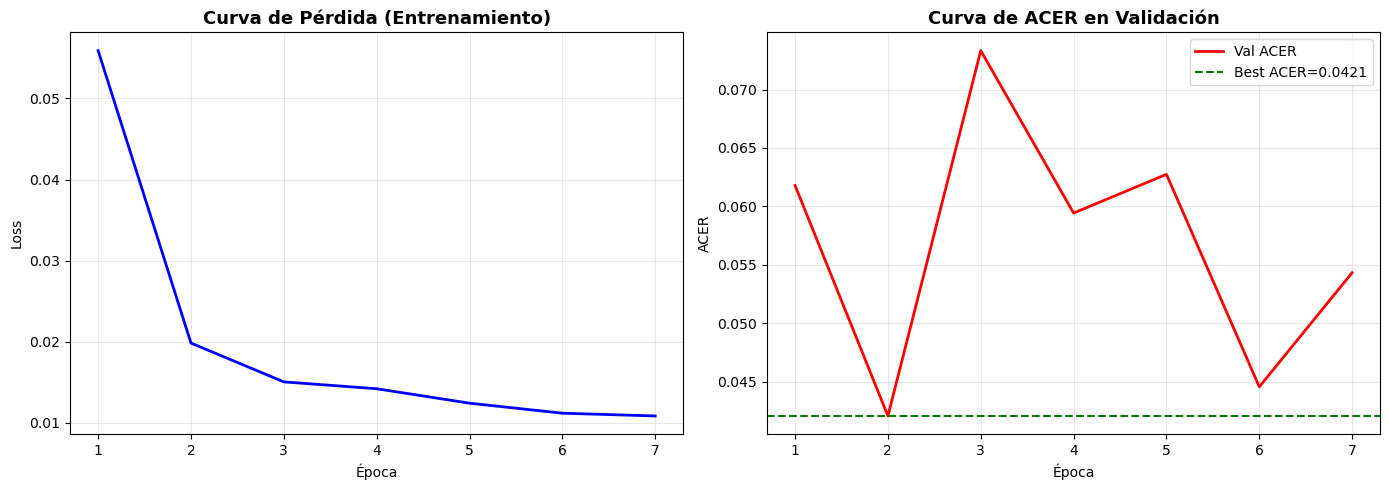

✅ Curvas guardadas como training_curves.png


In [12]:
# ==========================================
# CELDA 11: CURVAS DE ENTRENAMIENTO
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(train_losses)+1), train_losses, 'b-', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].set_title('Curva de Pérdida (Entrenamiento)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, len(val_acers)+1), val_acers, 'r-', linewidth=2, label='Val ACER')
axes[1].axhline(y=best_val_acer, color='g', linestyle='--', label=f'Best ACER={best_val_acer:.4f}')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('ACER')
axes[1].set_title('Curva de ACER en Validación', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Curvas guardadas como training_curves.png")

📊 Evaluando en TEST (LCC_FASD_evaluation)...


Evaluando: 100%|██████████| 237/237 [00:41<00:00,  5.75it/s]



📊 RESULTADOS EN TEST
  APCER:  0.0266 (2.66%)
  BPCER:  0.1178 (11.78%)
  ACER:   0.0722 (7.22%)
  HTER:   0.0722 (7.22%)
  EER:    0.0669 (6.69%)
  Acc:    0.9697 (96.97%)
  TP=7073, TN=277, FP=37, FN=193


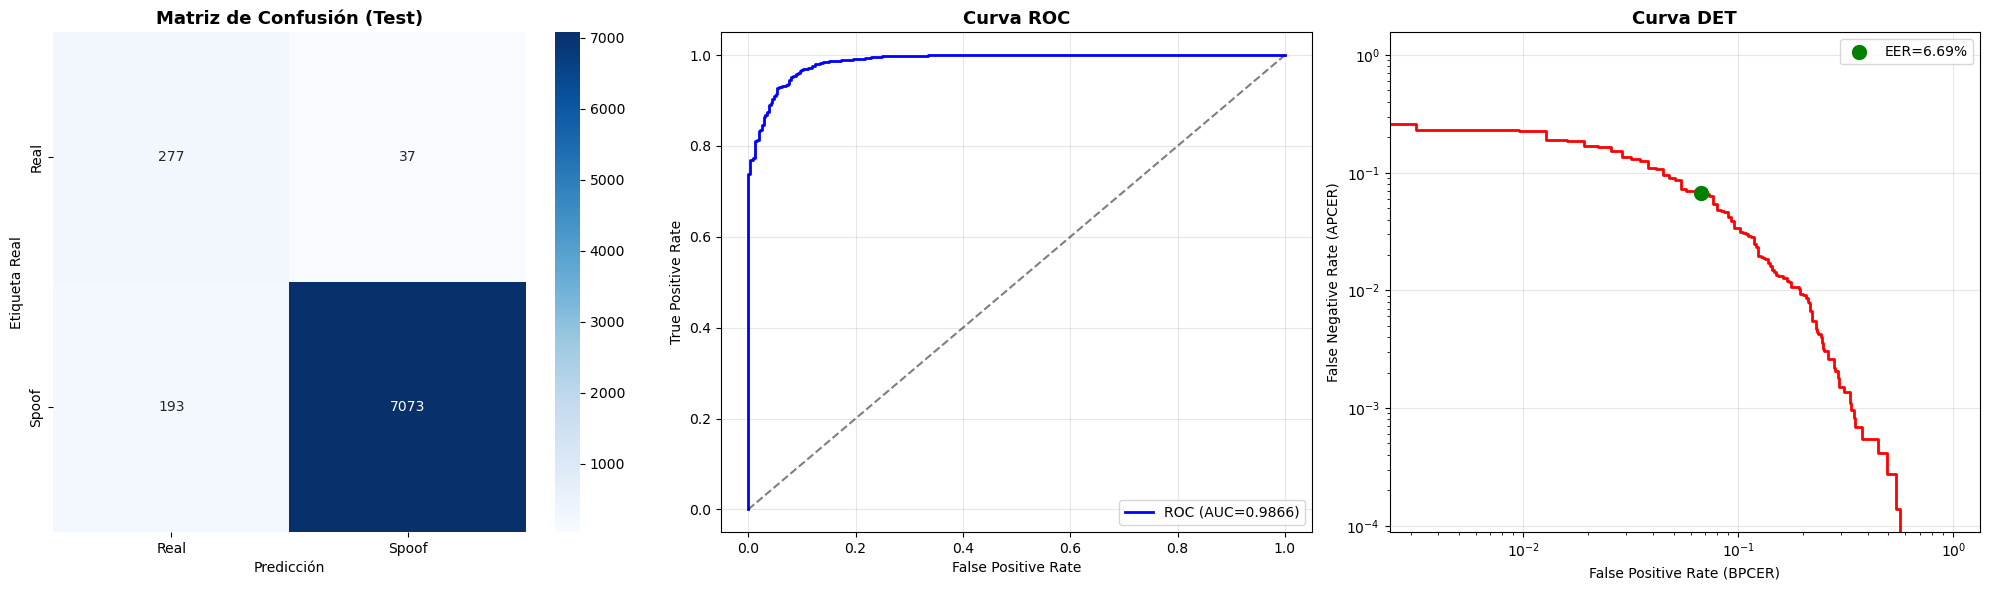

✅ Resultados guardados como test_results.png

🔧 Entrenando LBP + SVM (Baseline)...


LBP test spoof:  27%|██▋       | 134/500 [00:04<00:14, 25.72it/s]

In [ ]:
# ==========================================
# CELDA 12: EVALUACIÓN EN TEST + GRAD-CAM + BASELINE
# ==========================================

# Cargar mejor modelo
model.load_state_dict(torch.load('best_efficientnet_b0_lcc_fasd.pth'))
model.eval()

print("📊 Evaluando en TEST (LCC_FASD_evaluation)...")
test_metrics, y_true, y_pred, y_prob = evaluate_model(model, test_loader)
print_metrics(test_metrics, "RESULTADOS EN TEST")

# --- Matriz de confusión y curvas ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Real', 'Spoof'], yticklabels=['Real', 'Spoof'])
axes[0].set_title('Matriz de Confusión (Test)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Etiqueta Real')

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={np.trapz(tpr, fpr):.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fnr_det = 1 - tpr
axes[2].plot(fpr, fnr_det, 'r-', linewidth=2)
axes[2].set_xlabel('False Positive Rate (BPCER)')
axes[2].set_ylabel('False Negative Rate (APCER)')
axes[2].set_title('Curva DET', fontsize=13, fontweight='bold')
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)
eer_idx = np.argmin(np.abs(fpr - fnr_det))
axes[2].scatter([fpr[eer_idx]], [fnr_det[eer_idx]], color='green', s=100, zorder=5,
                label=f'EER={100*fpr[eer_idx]:.2f}%')
axes[2].legend()

plt.tight_layout()
plt.savefig('test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Resultados guardados como test_results.png")

# --- BASELINE LBP + SVM ---
def extract_lbp_features(image_path, radius=3, n_points=24):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(n_points + 2)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lbp = local_binary_pattern(img, n_points, radius, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    hist = hist.astype('float') / (hist.sum() + 1e-7)
    return hist

print("\n🔧 Entrenando LBP + SVM (Baseline)...")
MAX_SAMPLES = 500
train_features, train_labels_lbp = [], []
for cls_name, label in [('real', 0), ('spoof', 1)]:
    folder = DATA_ROOT / 'LCC_FASD_training' / cls_name
    files = [f for f in folder.glob("*") if f.suffix.lower() in ['.jpg', '.jpeg', '.png']][:MAX_SAMPLES]
    for fpath in tqdm(files, desc=f"LBP {cls_name}"):
        train_features.append(extract_lbp_features(str(fpath)))
        train_labels_lbp.append(label)

X_train_lbp = np.array(train_features)
y_train_lbp = np.array(train_labels_lbp)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_lbp)
svm = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=SEED)
svm.fit(X_train_scaled, y_train_lbp)

test_features, test_labels_lbp = [], []
for cls_name, label in [('real', 0), ('spoof', 1)]:
    folder = DATA_ROOT / 'LCC_FASD_evaluation' / cls_name
    files = [f for f in folder.glob("*") if f.suffix.lower() in ['.jpg', '.jpeg', '.png']][:MAX_SAMPLES]
    for fpath in tqdm(files, desc=f"LBP test {cls_name}"):
        test_features.append(extract_lbp_features(str(fpath)))
        test_labels_lbp.append(label)

X_test_lbp = np.array(test_features)
y_test_lbp = np.array(test_labels_lbp)
X_test_scaled = scaler.transform(X_test_lbp)
y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]
svm_metrics = compute_pad_metrics(y_test_lbp, y_pred_svm, y_prob_svm)
print_metrics(svm_metrics, "BASELINE LBP + SVM")

# --- Tabla comparativa ---
comparison = pd.DataFrame({
    'Métrica': ['APCER (%)', 'BPCER (%)', 'ACER (%)', 'HTER (%)', 'EER (%)', 'Accuracy (%)'],
    'LBP + SVM': [100*svm_metrics[k] for k in ['APCER','BPCER','ACER','HTER','EER','Accuracy']],
    'EfficientNet-B0': [100*test_metrics[k] for k in ['APCER','BPCER','ACER','HTER','EER','Accuracy']]
})
print("\n" + "="*60)
print("📊 TABLA COMPARATIVA DE RESULTADOS")
print("="*60)
print(comparison.to_string(index=False))
comparison.to_csv('results_comparison.csv', index=False)

# --- GRAD-CAM ---
print("\n🧠 Generando Grad-CAM...")
target_layers = [model.backbone.conv_head]
cam = GradCAM(model=model, target_layers=target_layers)

sample_images = []
for cls_name, label in [('real', 0), ('spoof', 1)]:
    folder = DATA_ROOT / 'LCC_FASD_evaluation' / cls_name
    files = [f for f in folder.glob("*") if f.suffix.lower() in ['.jpg', '.jpeg', '.png']][:2]
    for fpath in files:
        sample_images.append((str(fpath), label))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Grad-CAM: Interpretabilidad del Modelo', fontsize=16, fontweight='bold')

for i, (img_path, true_label) in enumerate(sample_images):
    row = i // 2
    col_base = (i % 2) * 2

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_normalized = val_transform(image=img_resized)['image'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(img_normalized)
        pred = torch.argmax(output, dim=1).item()
        prob = torch.softmax(output, dim=1)[0, 1].item()

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=img_normalized, targets=targets)[0, :]
    heatmap = np.uint8(255 * grayscale_cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    cam_image = cv2.addWeighted(heatmap, 0.5, img_resized, 0.5, 0)

    axes[row, col_base].imshow(img_resized)
    axes[row, col_base].set_title(
        f'Real: {"Real" if true_label==0 else "Spoof"}\nPred: {"Real" if pred==0 else "Spoof"} ({prob:.2f})',
        fontsize=11, fontweight='bold', color='green' if pred == true_label else 'red')
    axes[row, col_base].axis('off')

    axes[row, col_base+1].imshow(cam_image.astype(np.uint8))
    axes[row, col_base+1].set_title(
        f'Grad-CAM\n{"✓ Correcto" if pred==true_label else "✗ Incorrecto"}',
        fontsize=11, fontweight='bold')
    axes[row, col_base+1].axis('off')

plt.tight_layout()
plt.savefig('gradcam_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grad-CAM guardado como gradcam_analysis.png")

print("\n" + "="*60)
print(" ¡PROYECTO COMPLETADO CON ÉXITO!")
print("="*60)
print("📁 Archivos generados:")
print("   - eda_distribution.png")
print("   - training_curves.png")
print("   - test_results.png")
print("   - gradcam_analysis.png")
print("   - results_comparison.csv")
print("   - best_efficientnet_b0_lcc_fasd.pth")
print("\n Pipeline completo de anti-spoofing.")

🔬 Generando Análisis Avanzados de Visión Artificial...
✅ Imagen real cargada: data/lcc_fasd/LCC_FASD/LCC_FASD_evaluation/real/real_91.png
✅ Imagen spoof cargada: data/lcc_fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_4845.png


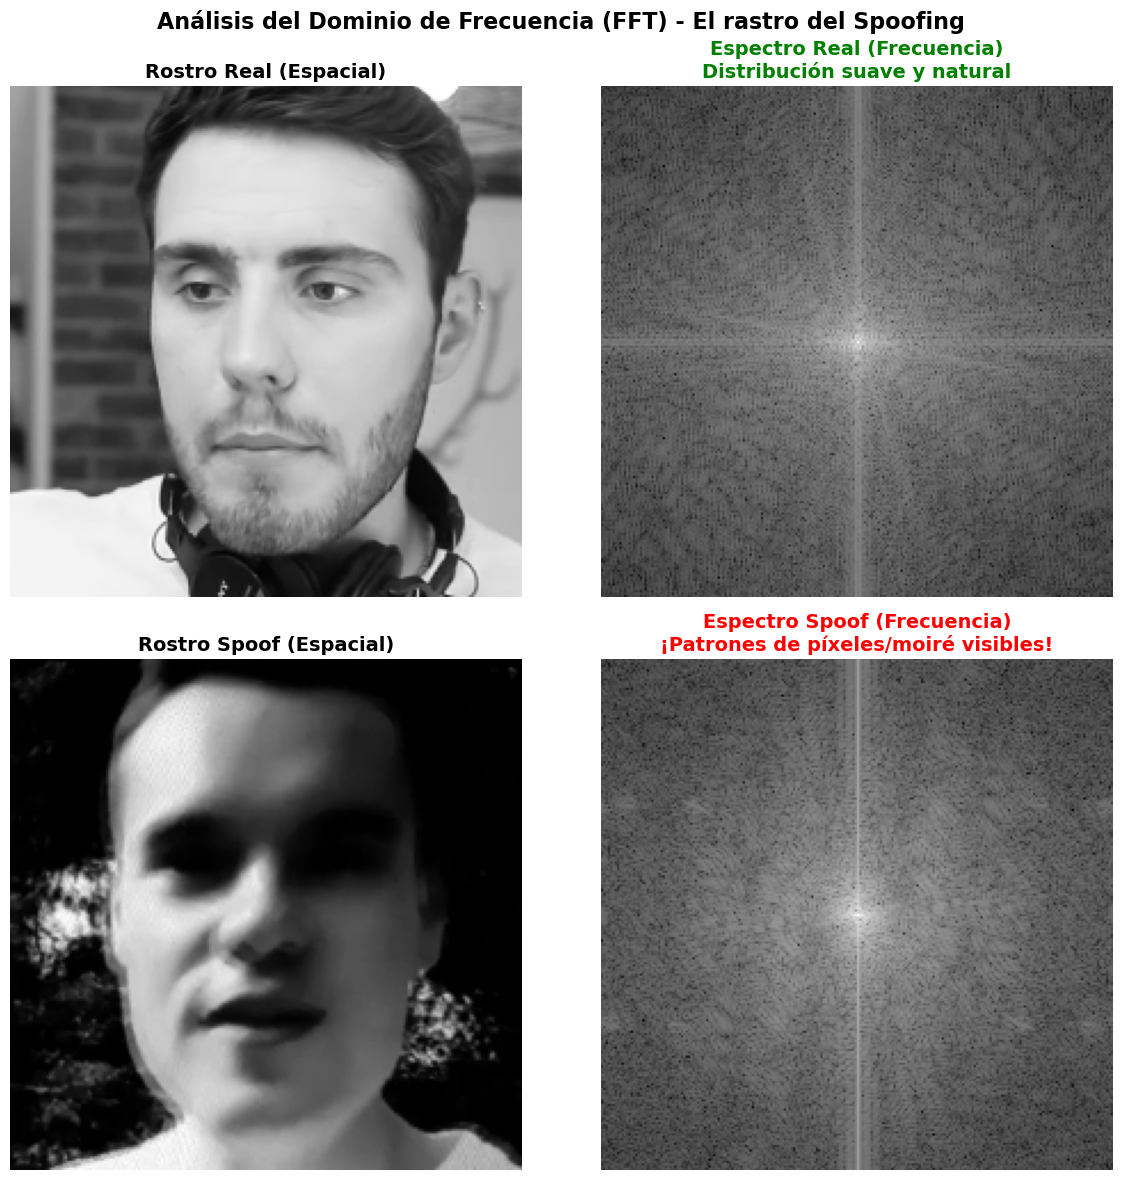

✅ Análisis FFT guardado.


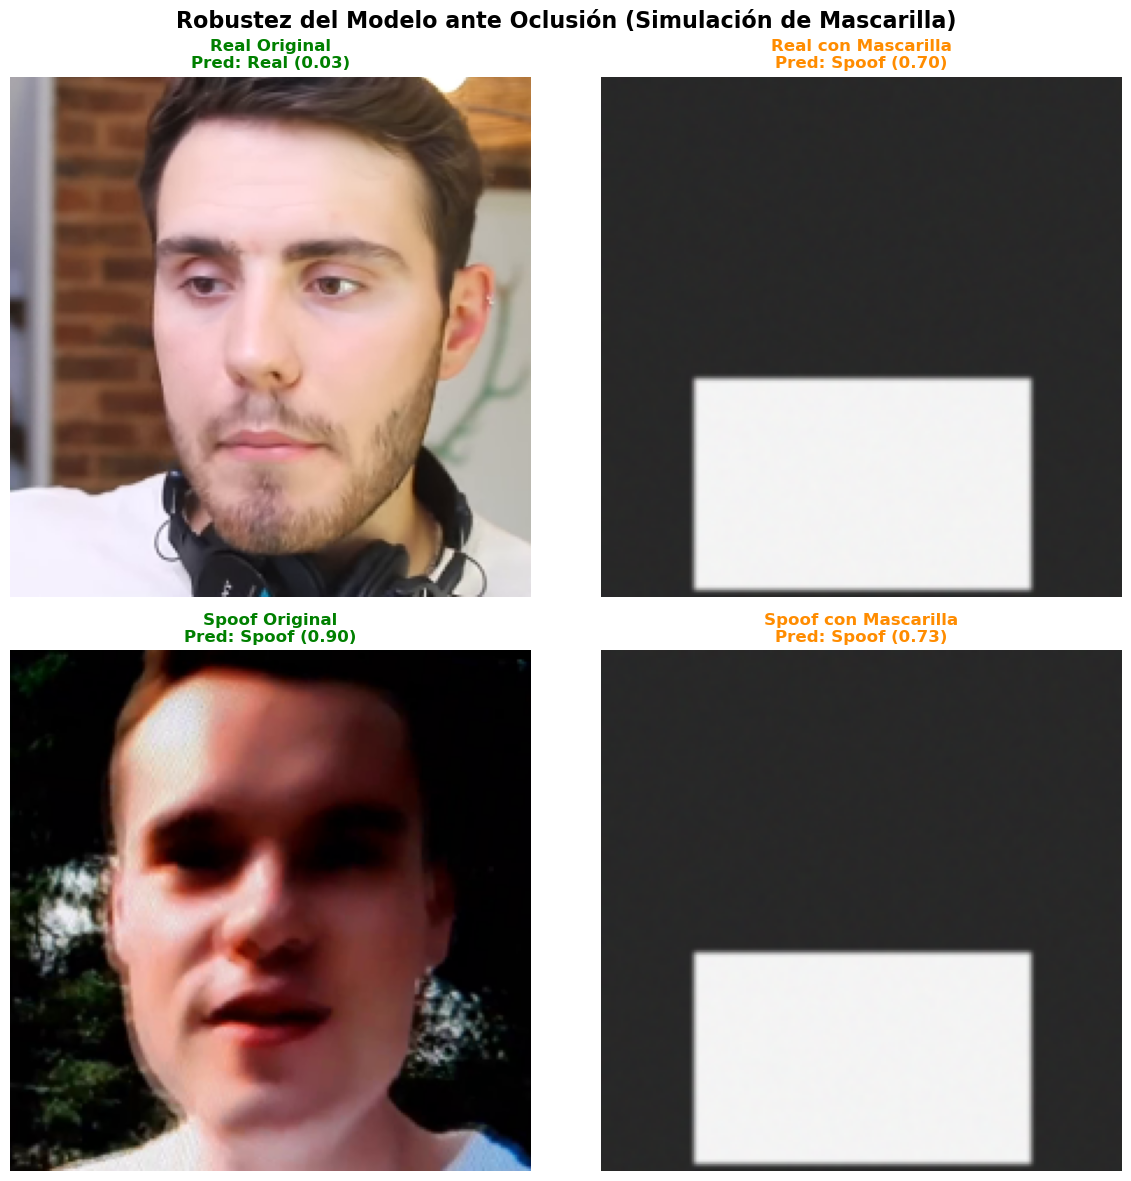

✅ Prueba de robustez con mascarillas guardada.


In [14]:
# ==========================================
# CELDA EXTRA: ANÁLISIS DE FRECUENCIA (FFT) Y SIMULACIÓN DE MASCARILLAS
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import torch

print("🔬 Generando Análisis Avanzados de Visión Artificial...")

# Asegurar que el modelo está cargado y en evaluación
model.load_state_dict(torch.load('best_efficientnet_b0_lcc_fasd.pth'))
model.eval()

# --- Búsqueda de archivos a prueba de fallos ---
real_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
    real_files.extend(list((DATA_ROOT / 'LCC_FASD_evaluation' / 'real').glob(ext)))
real_path = str(real_files[0])

spoof_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
    spoof_files.extend(list((DATA_ROOT / 'LCC_FASD_evaluation' / 'spoof').glob(ext)))
spoof_path = str(spoof_files[0])

print(f"✅ Imagen real cargada: {real_path}")
print(f"✅ Imagen spoof cargada: {spoof_path}")

# --- 1. MÁSCARA DE FRECUENCIA (FFT) ---
def get_fft_magnitude(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224, 224))
    # Aplicar Transformada Rápida de Fourier
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1)
    return img, magnitude_spectrum

# Generar las variables que causaban el error
real_img, real_fft = get_fft_magnitude(real_path)
spoof_img, spoof_fft = get_fft_magnitude(spoof_path)

# Graficar FFT
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Análisis del Dominio de Frecuencia (FFT) - El rastro del Spoofing', fontsize=16, fontweight='bold')

axes[0, 0].imshow(real_img, cmap='gray')
axes[0, 0].set_title('Rostro Real (Espacial)', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(real_fft, cmap='gray')
axes[0, 1].set_title('Espectro Real (Frecuencia)\nDistribución suave y natural', fontsize=14, fontweight='bold', color='green')
axes[0, 1].axis('off')

axes[1, 0].imshow(spoof_img, cmap='gray')
axes[1, 0].set_title('Rostro Spoof (Espacial)', fontsize=14, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(spoof_fft, cmap='gray')
axes[1, 1].set_title('Espectro Spoof (Frecuencia)\n¡Patrones de píxeles/moiré visibles!', fontsize=14, fontweight='bold', color='red')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('fft_frequency_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Análisis FFT guardado.")

# --- 2. SIMULACIÓN DE MASCARILLA MÉDICA (OCLUSIÓN) ---
def apply_surgical_mask(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224)).astype(np.uint8)
    
    # Crear una máscara negra del tamaño de la imagen
    mask = np.zeros((224, 224, 3), dtype=np.uint8)
    # Dibujar un rectángulo blanco que simula la mascarilla (cubre nariz y boca)
    cv2.rectangle(mask, (40, 130), (184, 220), (255, 255, 255), -1)
    
    # Aplicar un poco de textura/sombra a la mascarilla para que no sea plana
    noise = np.random.randint(180, 220, (224, 224, 3), dtype=np.uint8)
    mask_img = cv2.addWeighted(mask, 0.8, noise, 0.2, 0)
    mask_img = cv2.GaussianBlur(mask_img, (5,5), 0)
    
    # Superponer la mascarilla en la cara
    masked_face = np.where(mask_img > 0, mask_img, img)
    return img, masked_face

# Predecir con el modelo
def predict_face(face_array):
    img_norm = val_transform(image=face_array)['image'].unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(img_norm)
        prob = torch.softmax(output, dim=1)[0, 1].item()
        pred = "Spoof" if prob > 0.5 else "Real"
    return pred, prob

# Probar con 1 real y 1 spoof
orig_real, masked_real = apply_surgical_mask(real_path)
orig_spoof, masked_spoof = apply_surgical_mask(spoof_path)

pred_orig_real, prob_orig_real = predict_face(orig_real)
pred_mask_real, prob_mask_real = predict_face(masked_real)
pred_orig_spoof, prob_orig_spoof = predict_face(orig_spoof)
pred_mask_spoof, prob_mask_spoof = predict_face(masked_spoof)

# Graficar Mascarillas
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Robustez del Modelo ante Oclusión (Simulación de Mascarilla)', fontsize=16, fontweight='bold')

axes[0, 0].imshow(orig_real)
axes[0, 0].set_title(f'Real Original\nPred: {pred_orig_real} ({prob_orig_real:.2f})', fontsize=12, fontweight='bold', color='green')
axes[0, 0].axis('off')

axes[0, 1].imshow(masked_real)
axes[0, 1].set_title(f'Real con Mascarilla\nPred: {pred_mask_real} ({prob_mask_real:.2f})', fontsize=12, fontweight='bold', color='darkorange')
axes[0, 1].axis('off')

axes[1, 0].imshow(orig_spoof)
axes[1, 0].set_title(f'Spoof Original\nPred: {pred_orig_spoof} ({prob_orig_spoof:.2f})', fontsize=12, fontweight='bold', color='green')
axes[1, 0].axis('off')

axes[1, 1].imshow(masked_spoof)
axes[1, 1].set_title(f'Spoof con Mascarilla\nPred: {pred_mask_spoof} ({prob_mask_spoof:.2f})', fontsize=12, fontweight='bold', color='darkorange')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('mask_robustness.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Prueba de robustez con mascarillas guardada.")